# Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import re

In [2]:

# Set the global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Data

In [3]:
# Maaslin2 results
NR_vs_OA_maaslin2 = pd.read_csv("./99_Original_Data/pathabundance_maaslin2_OAvsNR_output.tsv", sep="\t")
NR_vs_R_maaslin2 = pd.read_csv("./99_Original_Data/pathabundance_maaslin2_OAvsNR_output.tsv", sep="\t")

# for maaslin2 results, the feature names is changed so that special characters are replaced with dot. change to its original form using the path_mat rownames denoted like *PWY*:*
## example SALVADEHYPOX.PWY..adenosine.nucleotides.degradation.II -> SALVADEHYPOX-PWY: adenosine nucleotides degradation II
# functional pathway matrix
path_mat = pd.read_csv("./99_Original_Data/pathabundance_merged_final.tsv", sep = '\t', index_col=0)

# change column name removing _Abundance suffix
path_mat.columns = [col.replace('_Abundance', '') for col in path_mat.columns]
# 원본 rownames 추출
original_pathways = path_mat.index.tolist()

# 3. 영문자와 숫자만 추출하여 매핑 딕셔너리 생성
def make_alnum_key(text):
    """특수기호, 점, 공백 등을 모두 제거하고 알파벳과 숫자만 남김"""
    if not isinstance(text, str):
        return str(text)
    return re.sub(r'[^a-zA-Z0-9]', '', text)

# { '알파벳숫자만있는키': '특수기호가포함된원본이름' }
# 예: {'PWY66391fattyacidbetaoxidationVImammalianperoxisome': 'PWY66-391: fatty acid &beta;-oxidation VI (mammalian peroxisome)'}
pathway_mapping = {make_alnum_key(name): name for name in original_pathways}

# 4. MaAsLin2 결과의 feature 컬럼 원상복구 함수 적용
def restore_from_mapping(maaslin_name):
    key = make_alnum_key(maaslin_name)
    # 딕셔너리에 키가 있으면 완벽한 원본 이름을 반환하고, 없으면 원래 maaslin_name 반환
    return pathway_mapping.get(key, maaslin_name)

NR_vs_OA_maaslin2['feature'] = NR_vs_OA_maaslin2['feature'].apply(restore_from_mapping)
NR_vs_R_maaslin2['feature'] = NR_vs_R_maaslin2['feature'].apply(restore_from_mapping)

# metadata
metadata = pd.read_csv("/home/sebin595/project/0.RA_oral_microbiome/for_paper_submission/01_Processed_Data/cleaned_metadata.tsv", sep='\t', index_col=1)
ra_metadata = pd.read_csv("/home/sebin595/project/0.RA_oral_microbiome/for_paper_submission/01_Processed_Data/cleaned_metadata_RA.tsv", sep='\t', index_col=0)
metadata['diagnosis'] = metadata['diagnosis'].replace({'Non_RA': 'OA'})
metadata = metadata.merge(ra_metadata['Responder_Status'], left_index=True, right_index=True, how='left')

# Analysis

## Figure 3A

In [4]:
nr_vs_oa = NR_vs_OA_maaslin2.copy()
r_vs_nr = NR_vs_R_maaslin2.copy()

# Convert numeric columns
nr_vs_oa['coef'] = pd.to_numeric(nr_vs_oa['coef'], errors='coerce')
nr_vs_oa['qval'] = pd.to_numeric(nr_vs_oa['qval'], errors='coerce')
r_vs_nr['coef'] = pd.to_numeric(r_vs_nr['coef'], errors='coerce')
r_vs_nr['qval'] = pd.to_numeric(r_vs_nr['qval'], errors='coerce')

# Filter for diagnosis comparisons and qval < 0.25
nr_vs_oa_filtered = nr_vs_oa[
    (nr_vs_oa['metadata'] == 'Comparison_Group') & 
    (nr_vs_oa['qval'] < 0.25)
].copy()

# Filter for non-responder comparisons and qval < 0.25
r_vs_nr_filtered = r_vs_nr[
    (r_vs_nr['metadata'] == 'Comparison_Group') & 
    (r_vs_nr['qval'] < 0.25)
].copy()


# Sort by coefficient for better visualization
nr_vs_oa_filtered = nr_vs_oa_filtered.sort_values('coef')
r_vs_nr_filtered = r_vs_nr_filtered.sort_values('coef')

/tmp/ipykernel_3739477/335200427.py:110: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nsmallest(top_n_labels, "qval"))
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


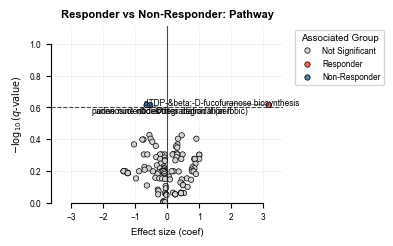

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

def get_description_only(name):
    return name.split(":", 1)[-1].strip() if ":" in name else name

def stars(q):
    return "***" if q < 0.001 else "**" if q < 0.01 else "*" if q < 0.05 else ""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from adjustText import adjust_text

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

def get_description_only(name):
    return name.split(":", 1)[-1].strip() if ":" in name else name

def draw_pathway_volcano_plot(
    pathway_maaslin2,
    title="Responder vs Non-Responder: Pathway",
    fc_thresh=0.0,        # pathway는 effect-size 컷오프 미사용이 기본 (>0 주면 점선+필터 활성)
    q_thresh=0.05,        # MaAsLin2 qval(BH 보정)이라 곧 FDR 컷오프
    top_n_labels=5,       # 각 그룹별 라벨 개수
    xlim=None,
    ylim=None,
    save_path="./03_Output_Figures/Figure_3B_RvsNR_Pathway_Volcano.pdf",
):
    # -----------------------------
    # 1. Prepare dataframe
    # -----------------------------
    df = pathway_maaslin2.drop_duplicates("feature").copy()

    if "qval" not in df.columns:
        raise ValueError("df must contain 'qval' column.")
    df = df.dropna(subset=["coef", "qval"])
    df = df[df["metadata"] == "Comparison_Group"]  # MaAsLin2 결과 중 비교 그룹만

    df["qval"] = df["qval"].replace(0, np.nextafter(0, 1))
    df["neg_log10_q"] = -np.log10(df["qval"])

    # --- coefficient 부호 반전: Responder를 양수 쪽으로 ---
    df["coef"] = -df["coef"]

    # -----------------------------
    # 2. Significance & direction
    #    coef>0 → NR enriched, coef<0 → R enriched
    #    ⚠️ 부호 방향은 MaAsLin2 reference level 의존 — value 컬럼으로 확인
    # -----------------------------
    conditions = [
        (df["qval"] < q_thresh) & (df["coef"] >  fc_thresh),   # 이제 coef>0 = Responder
        (df["qval"] < q_thresh) & (df["coef"] < -fc_thresh),   # coef<0 = Non-Responder
    ]
    choices = ["Responder", "Non-Responder"]   # ← 순서 반전
    df["Status"] = np.select(conditions, choices, default="Not Significant")

    # -----------------------------
    # 3. Plotting setup
    # -----------------------------
    if xlim is None:
        xpad = (df["coef"].max() - df["coef"].min()) * 0.1 + 1e-9
        m = max(abs(df["coef"].min()), abs(df["coef"].max())) + xpad
        xlim = (-m, m)                       # 0 기준 대칭
    if ylim is None:
        ylim = (0, df["neg_log10_q"].max() + 0.5)

    plt.figure(figsize=(3, 2.3))

    custom_palette = {
        "Responder": "#FF6347",        # SteelBlue (R enriched)
        "Non-Responder": "#4682B4",    # Tomato (NR enriched)
        "Not Significant": "lightgray",
    }
    hue_order = ["Not Significant", "Responder", "Non-Responder"]

    # -----------------------------
    # 4. Scatter
    # -----------------------------
    sns.scatterplot(
        data=df, x="coef", y="neg_log10_q",
        hue="Status", hue_order=hue_order, palette=custom_palette,
        s=15, alpha=1, edgecolor="black", linewidth=0.5, legend="brief",
    )

    # -----------------------------
    # 5. Threshold lines
    # -----------------------------
    plt.axhline(-np.log10(q_thresh), color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    plt.axvline(0, color="black", linewidth=0.8, alpha=0.7)
    if fc_thresh > 0:
        plt.axvline( fc_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
        plt.axvline(-fc_thresh, color="black", linestyle="--", linewidth=0.8, alpha=0.7)

    # -----------------------------
    # 6. Label top significant features
    # -----------------------------
    texts = []
    if "feature" in df.columns:
        sig_df = df[df["Status"] != "Not Significant"]
        if not sig_df.empty:
            top_n = (
                sig_df.groupby("Status", group_keys=False)
                .apply(lambda x: x.nsmallest(top_n_labels, "qval"))
            )
            for _, row in top_n.iterrows():
                texts.append(
                    plt.text(
                        row["coef"], row["neg_log10_q"],
                        get_description_only(str(row["feature"])),
                        fontsize=6, ha="center", va="center",
                    )
                )
            if texts:
                adjust_text(
                    texts,
                    arrowprops=dict(arrowstyle="-", color="black", lw=0.5, alpha=0.6),
                    expand_points=(1.5, 1.5),
                )

    # -----------------------------
    # 7. Final layout
    # -----------------------------
    plt.title(title, fontsize=8, weight="bold")
    plt.xlabel("Effect size (coef)", fontsize=7)
    plt.ylabel(r"$-\log_{10}(q\text{-value})$", fontsize=7)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid(alpha=0.3, linestyle="--", linewidth=0.5)
    plt.tick_params(axis="x", labelsize=6)
    plt.tick_params(axis="y", labelsize=6)
    plt.legend(title="Associated Group", loc="upper right", bbox_to_anchor=(1.45, 1),
               fontsize=6, title_fontsize=7, frameon=True)
    sns.despine(trim=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Example usage
draw_pathway_volcano_plot(
    r_vs_nr,
    title="Responder vs Non-Responder: Pathway",
    fc_thresh=0.0,
    q_thresh=0.25,
    top_n_labels=5,
)

## Figure 3B

매칭: adenosine nucleotides degradation II
   -> SALVADEHYPOX-PWY: adenosine nucleotides degradation II
n = 35
Pearson r = 0.3447
p-value = 4.2602e-02


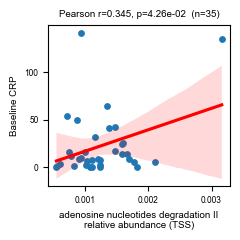

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
from scipy.stats import pearsonr, spearmanr

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ===== 설정 =====
target_pathway = "adenosine nucleotides degradation II"
clinical_var   = "CRP"
corr_func      = pearsonr      # 강건성 확인용으로 spearmanr로 교체 가능

# ===== 1. pathway index 매칭 (특수문자 무시 alnum 키) =====
def make_alnum_key(text):
    return re.sub(r'[^a-zA-Z0-9]', '', str(text)).lower()

def desc_only(name):
    d = name.split(":", 1)[-1] if ":" in name else name
    return d.split("|", 1)[0].strip()

idx_map = {}

path_mat_tss = path_mat.div(path_mat.sum(axis=0), axis=1)  # TSS normalization

for name in path_mat_tss.index:
    idx_map.setdefault(make_alnum_key(desc_only(name)), name)

k = make_alnum_key(target_pathway)
if k in idx_map:
    matched_feature = idx_map[k]
else:
    cands = [orig for key, orig in idx_map.items() if k in key or key in k]
    if not cands:
        raise KeyError(f"매칭 실패: {target_pathway}")
    matched_feature = cands[0]
print(f"매칭: {target_pathway}\n   -> {matched_feature}")

# ===== 2. abundance & CRP 정렬 (RA 환자 한정) =====
common = path_mat_tss.columns.intersection(ra_metadata.index)

x = pd.to_numeric(path_mat_tss.loc[matched_feature, common], errors="coerce")   # pathway abundance
y = pd.to_numeric(ra_metadata.loc[common, clinical_var], errors="coerce")        # baseline CRP

valid = x.notna() & y.notna()
x, y = x[valid], y[valid]

# ===== 3. 상관 =====
r, p = corr_func(x, y)
method = "Pearson r" if corr_func is pearsonr else "Spearman ρ"
print(f"n = {len(x)}")
print(f"{method} = {r:.4f}")
print(f"p-value = {p:.4e}")

# ===== 4. scatter + regression =====
plt.figure(figsize=(2.5, 2.5))
sns.regplot(x=x, y=y, scatter_kws={"s": 15, "alpha": 1}, line_kws={"color": "red"})
plt.xlabel("adenosine nucleotides degradation II\nrelative abundance (TSS)", fontsize=7)
plt.ylabel("Baseline CRP", fontsize=7)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title(f"{method}={r:.3f}, p={p:.2e}  (n={len(x)})", fontsize=7)
plt.tight_layout()
plt.savefig("./03_Output_Figures/Figure_3E_adenosine_CRP.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Figure 3C,D

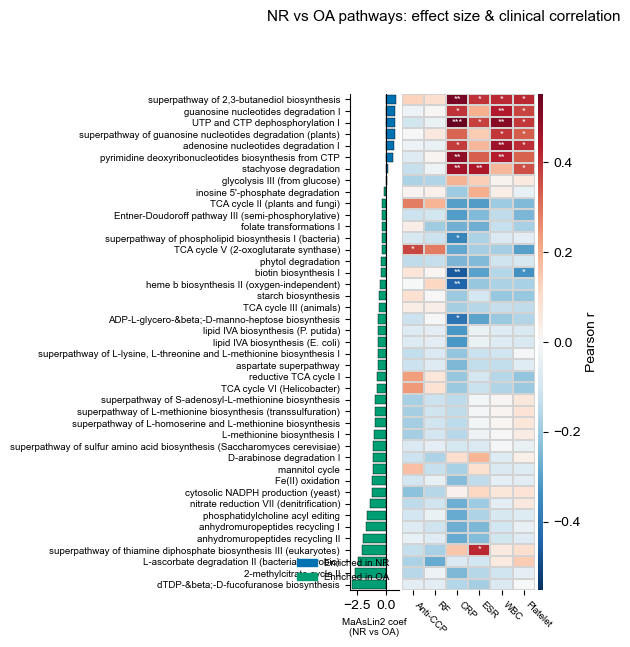

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import pearsonr   # 필요시 spearmanr로 교체
from matplotlib.patches import Patch

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

clinical_vars = ["Anti_ccp", "RF", "CRP", "ESR", "WBC", "Plt"]
clin_labels = {"Anti_ccp": "Anti-CCP", "Plt": "Platelet"}

# --- TSS 정규화 (별도 matrix로) ---
# UNMAPPED / UNINTEGRATED 행이 있으면 합산에 들어가지 않게 먼저 제거
mask = ~path_mat.index.str.contains("UNMAPPED|UNINTEGRATED", case=False, na=False)
path_mat_tss = path_mat.loc[mask].div(path_mat.loc[mask].sum(axis=0), axis=1)

# --- OA vs NR 유의 feature ---
oa_feats = nr_vs_oa_filtered.drop_duplicates("feature")["feature"].tolist()
coef_oa = (nr_vs_oa.drop_duplicates("feature").set_index("feature").reindex(oa_feats))

feats_in_mat = [f for f in oa_feats if f in path_mat_tss.index]
common = path_mat_tss.columns.intersection(ra_metadata.index)   # RA 환자 한정
abund = path_mat_tss.loc[feats_in_mat, common].T.apply(pd.to_numeric, errors="coerce")
clin  = ra_metadata.loc[common, clinical_vars].apply(pd.to_numeric, errors="coerce")

# --- 상관 ---
corr_df  = pd.DataFrame(index=feats_in_mat, columns=clinical_vars, dtype=float)
annot_df = pd.DataFrame(index=feats_in_mat, columns=clinical_vars, dtype=str)
for v in clinical_vars:
    for f in feats_in_mat:
        d = pd.concat([abund[f], clin[v]], axis=1).dropna()
        if len(d) > 2:
            r, p = pearsonr(d.iloc[:, 0], d.iloc[:, 1])
            corr_df.loc[f, v] = r
            annot_df.loc[f, v] = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        else:
            corr_df.loc[f, v], annot_df.loc[f, v] = np.nan, ""

# --- coef 기준 정렬 (양수 → 음수) ---
order = coef_oa.loc[feats_in_mat, "coef"].dropna().sort_values(ascending=False).index.tolist()
coef_plot  = coef_oa.loc[order]
corr_plot  = corr_df.loc[order].rename(columns=clin_labels)
annot_plot = annot_df.loc[order].rename(columns=clin_labels)

def get_description_only(name):
    return name.split(":", 1)[-1].strip() if ":" in name else name
ylabels = [get_description_only(f) for f in order]

# --- layout ---
n = len(order)
fig = plt.figure(figsize=(2.5, max(3, 0.15 * n)))
gs = fig.add_gridspec(1, 3, width_ratios=[2.2, len(clinical_vars), 0.25], wspace=0.05)
ax_bar, ax_hm, ax_cb = (fig.add_subplot(gs[0, i]) for i in (0, 1, 2))

# barplot (heatmap과 같은 위→아래 순서)
# coef>0 = NR enriched → blue / coef<0 = OA enriched → green
# ⚠️ 부호 방향은 MaAsLin2 reference level 의존 — value 컬럼으로 확인
NR_COLOR, OA_COLOR = "#0072B2", "#009E73"
colors = [NR_COLOR if c > 0 else OA_COLOR for c in coef_plot["coef"]]
ypos = np.arange(n)
ax_bar.barh(ypos, coef_plot["coef"], color=colors, edgecolor="black", linewidth=0.3)
ax_bar.axvline(0, color="black", lw=0.8)
ax_bar.set_yticks(ypos)
ax_bar.set_yticklabels(ylabels, fontsize=7)
ax_bar.set_ylim(-0.5, n - 0.5)
ax_bar.invert_yaxis()                      # row0(가장 큰 양수)을 위로 → heatmap과 정렬
ax_bar.set_xlabel("MaAsLin2 coef\n(NR vs OA)", fontsize=7)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.legend(handles=[Patch(color=NR_COLOR, label="Enriched in NR"),
                       Patch(color=OA_COLOR, label="Enriched in OA")],
              fontsize=7, loc="lower right", frameon=False)

# heatmap
max_corr = np.nanmax(np.abs(corr_plot.values))
sns.heatmap(corr_plot, annot=annot_plot, fmt="", cmap="RdBu_r", center=0,
            vmin=-max_corr, vmax=max_corr, linewidths=0.3, linecolor="lightgray",
            annot_kws={"size": 7}, cbar=True, cbar_ax=ax_cb,
            cbar_kws={"label": "Pearson r"}, ax=ax_hm)
ax_hm.set_yticks([]); ax_hm.set_ylabel("")
ax_hm.set_xticklabels(ax_hm.get_xticklabels(), rotation=315, ha="left", fontsize=7)

fig.suptitle("NR vs OA pathways: effect size & clinical correlation", fontsize=11, y=1.01)
plt.savefig("./03_Output_Figures/Figure_3A_NRvsOA_revised.pdf", dpi=300, bbox_inches="tight")
plt.show()

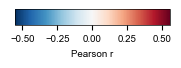

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Figure 및 컬러바가 들어갈 축(Axes) 생성
# figsize=(가로, 세로) 조절을 통해 컬러바의 비율을 맞출 수 있습니다.
fig, ax = plt.subplots(figsize=(2, 0.2)) 

# 이전 코드와 동일한 Colormap 및 데이터 범위(Normalize) 설정
cmap = plt.get_cmap("RdBu_r")
norm = mcolors.Normalize(vmin=-max_corr, vmax=max_corr)

# 빈 ScalarMappable 객체를 만들어 컬러바 생성
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) # 실제 데이터는 없으므로 빈 배열 전달

# 컬러바 그리기
cb = fig.colorbar(sm, cax=ax, orientation='horizontal')
cb.set_label("Pearson r", fontsize=7)
cb.ax.tick_params(labelsize=7)

# (선택 사항) 컬러바 테두리 두께 조절
cb.outline.set_linewidth(0.5)
cb.outline.set_edgecolor("black")

# 독립된 컬러바로 저장
plt.savefig("./03_Output_Figures/Figure_3A_colorbar_only.pdf", dpi=300, bbox_inches="tight")
plt.show()